In [1]:
# Install alibi (and its dependencies)
!pip install alibi[all]  scikit-learn pandas numpy

### Part1

In [4]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the datasets
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

# Separate features and target
X_train = train_df.drop(columns=['status'])
y_train = train_df['status']

X_test = test_df.drop(columns=['status'])
y_test = test_df['status']

# Apply MinMax normalization
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Reattach the labels
train_normalized = pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1)
test_normalized = pd.concat([X_test_scaled, y_test.reset_index(drop=True)], axis=1)

# Optional: Save the normalized datasets
train_normalized.to_csv('train_data_normalized.csv', index=False)
test_normalized.to_csv('test_data_normalized.csv', index=False)


In [4]:
# Display first 5 rows of the normalized training data
print("Normalized Training Data:")
print(train_normalized.head())

# Display first 5 rows of the normalized test data
print("\nNormalized Test Data:")
print(test_normalized.head())


Normalized Training Data:
   nb_dots  shortest_words_raw  length_hostname  nb_slash  longest_words_raw  \
0      0.6               0.250         0.306122  0.571429           0.384615   
1      0.0               0.000         0.285714  0.428571           0.102564   
2      0.0               0.500         0.102041  0.142857           0.038462   
3      0.6               0.125         0.775510  0.285714           0.192308   
4      1.0               0.000         0.183673  0.571429           0.358974   

   avg_words_raw  shortest_word_host  avg_word_host  longest_word_host  \
0       0.392857            0.133333       0.375000           0.416667   
1       0.253968            0.133333       0.343750           0.375000   
2       0.171429            0.266667       0.250000           0.166667   
3       0.333333            0.133333       0.484375           0.500000   
4       0.349206            0.533333       0.500000           0.333333   

   length_url  status  
0    0.359813       1  


### Part2

#### Logestic Regression

Accuracy on test set: 0.7444

Confusion Matrix:
[[793 166]
 [324 634]]


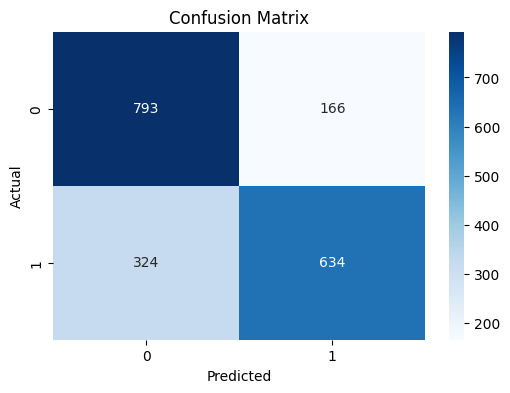


Top Positive Coefficients (indicate phishing):
longest_words_raw     10.091857
length_hostname        5.646977
shortest_word_host     5.285160
nb_slash               2.349439
nb_dots                2.160541
dtype: float64

Top Negative Coefficients (indicate legitimate):
shortest_words_raw   -0.355692
avg_words_raw        -0.536843
avg_word_host        -2.524603
longest_word_host    -2.978327
length_url           -4.107161
dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Separate features and labels
X_train_final = train_normalized.drop(columns=['status'])
y_train_final = train_normalized['status']

X_test_final = test_normalized.drop(columns=['status'])
y_test_final = test_normalized['status']

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_final, y_train_final)

# Predict on test set
y_pred = lr_model.predict(X_test_final)

# Evaluate performance
acc = accuracy_score(y_test_final, y_pred)
cm = confusion_matrix(y_test_final, y_pred)

print(f"Accuracy on test set: {acc:.4f}")
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Display feature coefficients
coefficients = pd.Series(lr_model.coef_[0], index=X_train_final.columns)
coefficients_sorted = coefficients.sort_values(ascending=False)

print("\nTop Positive Coefficients (indicate phishing):")
print(coefficients_sorted.head())

print("\nTop Negative Coefficients (indicate legitimate):")
print(coefficients_sorted.tail())


#### SVM

SVM Accuracy on test set: 0.7418

SVM Confusion Matrix:
[[793 166]
 [329 629]]


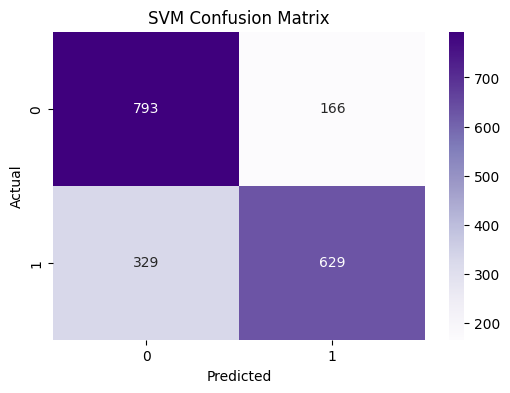


Top Positive SVM Coefficients (indicate phishing):
longest_words_raw     6.444757
shortest_word_host    3.100926
length_hostname       2.669003
nb_slash              1.121581
nb_dots               0.880893
dtype: float64

Top Negative SVM Coefficients (indicate legitimate):
shortest_words_raw    0.072593
longest_word_host    -0.396043
avg_words_raw        -1.096761
length_url           -2.382291
avg_word_host        -2.661663
dtype: float64


In [ ]:
from sklearn.svm import LinearSVC

# Train a linear SVM model
svm_model = LinearSVC(max_iter=10000)
svm_model.fit(X_train_final, y_train_final)

# Predict on test set
y_pred_svm = svm_model.predict(X_test_final)

# Evaluate performance
acc_svm = accuracy_score(y_test_final, y_pred_svm)
cm_svm = confusion_matrix(y_test_final, y_pred_svm)

print(f"SVM Accuracy on test set: {acc_svm:.4f}")
print("\nSVM Confusion Matrix:")
print(cm_svm)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

# Display feature coefficients
svm_coefficients = pd.Series(svm_model.coef_[0], index=X_train_final.columns)
svm_coefficients_sorted = svm_coefficients.sort_values(ascending=False)

print("\nTop Positive SVM Coefficients (indicate phishing):")
print(svm_coefficients_sorted.head())

print("\nTop Negative SVM Coefficients (indicate legitimate):")
print(svm_coefficients_sorted.tail())

SVM Accuracy on test set: 0.7986

SVM Confusion Matrix:
[[799 160]
 [226 732]]


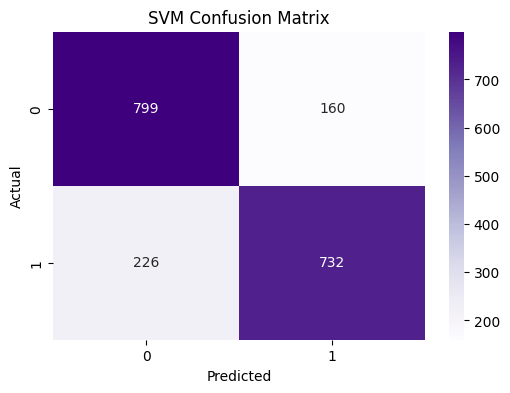

In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
X_train_final = train_normalized.drop(columns=['status'])
y_train_final = train_normalized['status']

X_test_final = test_normalized.drop(columns=['status'])
y_test_final = test_normalized['status']

# Train SVM with RBF kernel (nonlinear)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')  # you can tune C and gamma if needed
svm_model.fit(X_train_final, y_train_final)

# Predict on test data
y_pred_svm = svm_model.predict(X_test_final)

# Evaluate performance
svm_acc = accuracy_score(y_test_final, y_pred_svm)
svm_cm = confusion_matrix(y_test_final, y_pred_svm)

print(f"SVM Accuracy on test set: {svm_acc:.4f}")
print("\nSVM Confusion Matrix:")
print(svm_cm)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()



### Part3

#### Partial Dependence Plot

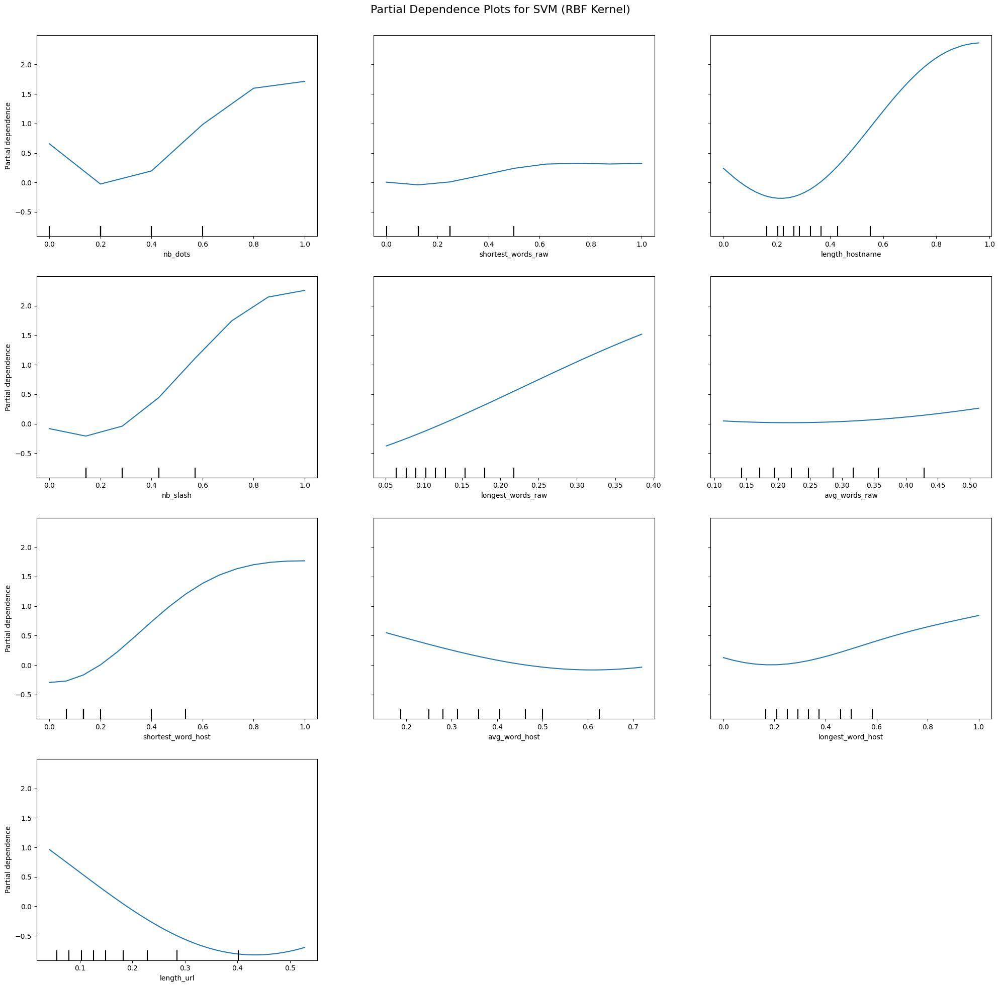

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Use decision_function since SVM with RBF doesn't support predict_proba by default
features = list(X_test_final.columns)

# Plot partial dependence for all features
fig, ax = plt.subplots(figsize=(20, 20))  # You may adjust figsize depending on number of features
display = PartialDependenceDisplay.from_estimator(
    svm_model,
    X_test_final,
    features,
    kind="average",  # 'average' PD plot (default)
    grid_resolution=50,
    ax=ax
)

plt.suptitle("Partial Dependence Plots for SVM (RBF Kernel)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


#### Individual Conditional Expectation (ICE) plots

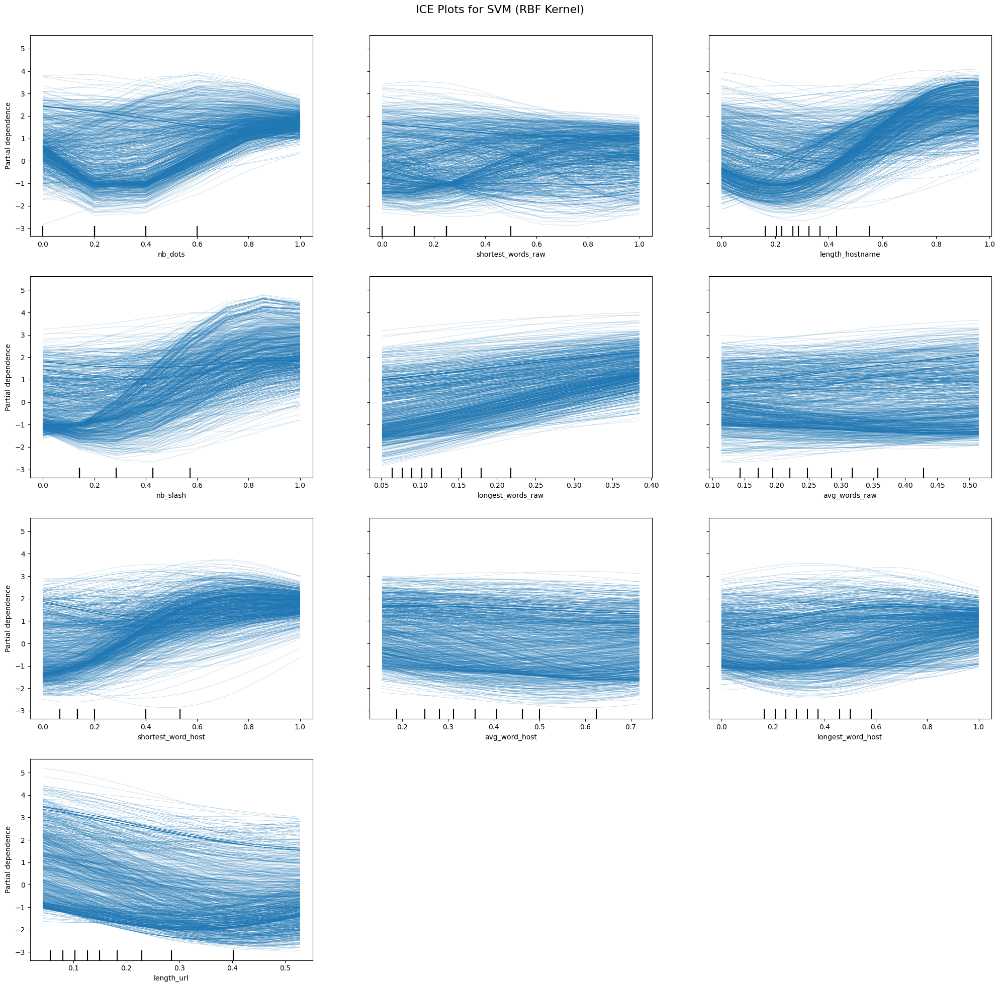

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# List of features to plot ICE for
features = list(X_test_final.columns)

# Plot ICE plots (one per feature)
# This might be a lot of plots if you have many features — consider plotting in batches if needed
fig, ax = plt.subplots(figsize=(20, 20))  # Adjust size depending on number of features
display = PartialDependenceDisplay.from_estimator(
    svm_model,
    X_test_final,
    features,
    kind="individual",  # ICE plots
    grid_resolution=50,
    ax=ax
)

plt.suptitle("ICE Plots for SVM (RBF Kernel)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


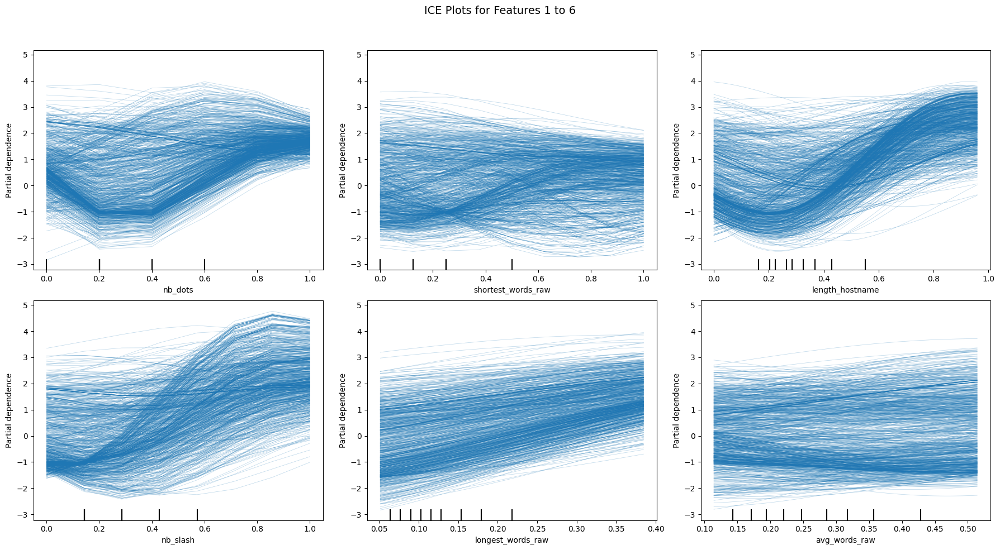

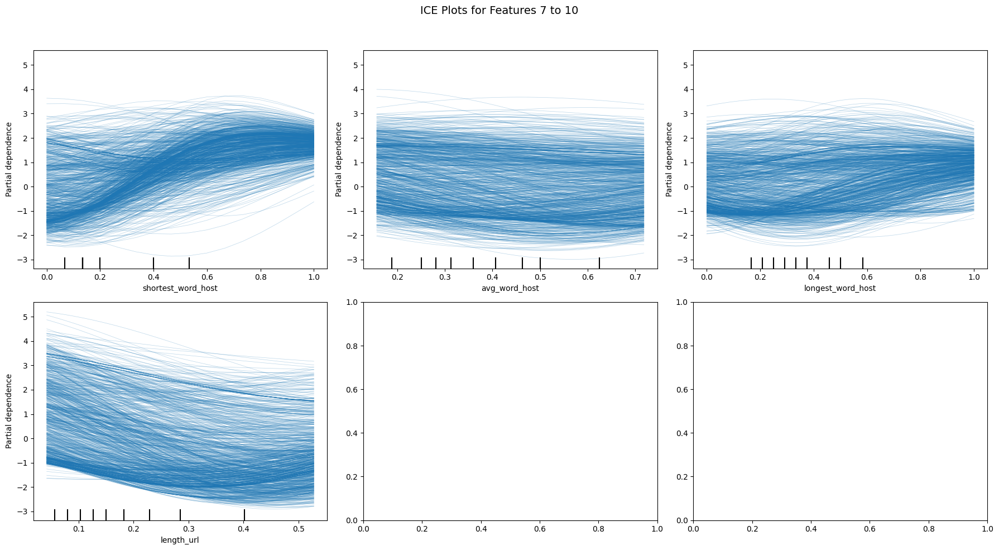

In [ ]:
from math import ceil
from sklearn.inspection import PartialDependenceDisplay

# Plot in smaller groups (e.g., 6 features per batch)
batch_size = 6
for i in range(0, len(features), batch_size):
    subset = features[i:i+batch_size]
    n = len(subset)
    rows = ceil(n / 3)
    fig, ax = plt.subplots(nrows=rows, ncols=3, figsize=(18, 5 * rows))
    ax = ax.flatten()[:n]  # Adjust to match the number of features

    display = PartialDependenceDisplay.from_estimator(
        svm_model,
        X_test_final,
        subset,
        kind="individual",  # ICE
        grid_resolution=50,
        ax=ax
    )

    plt.suptitle(f"ICE Plots for Features {i+1} to {i+len(subset)}", fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()


#### Accumulated local effects

In [ ]:
!pip install PyALE

INFO:PyALE._ALE_generic:Discrete feature detected.


<Figure size 600x400 with 0 Axes>

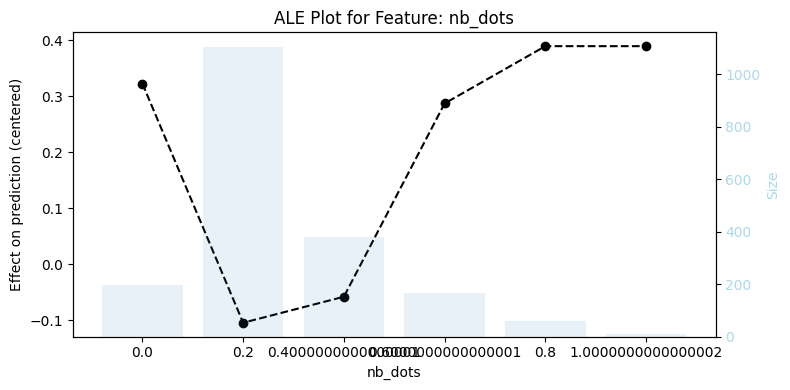

INFO:PyALE._ALE_generic:Discrete feature detected.


<Figure size 600x400 with 0 Axes>

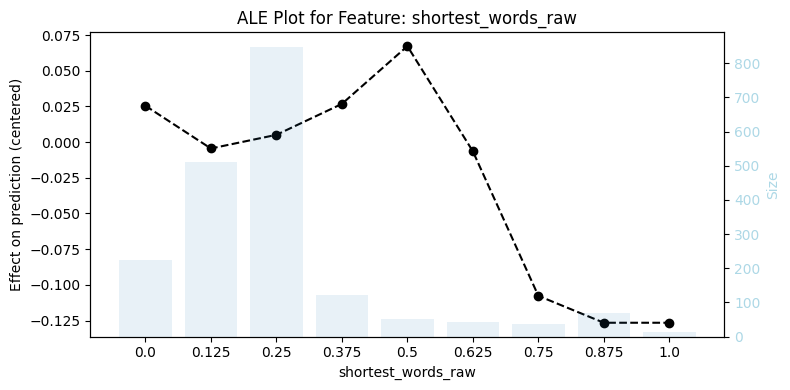

INFO:PyALE._ALE_generic:Continuous feature detected.


<Figure size 600x400 with 0 Axes>

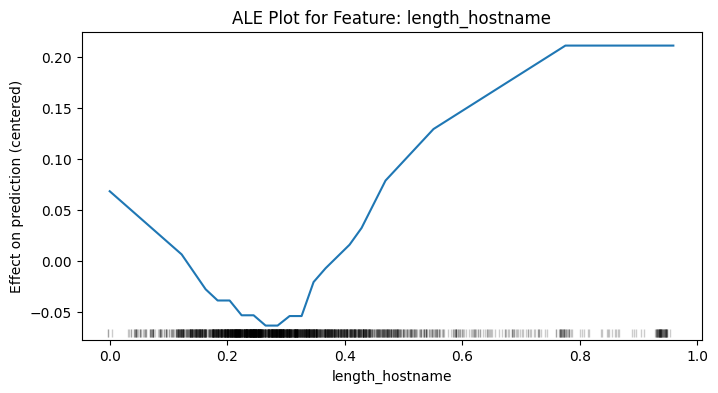

INFO:PyALE._ALE_generic:Discrete feature detected.


<Figure size 600x400 with 0 Axes>

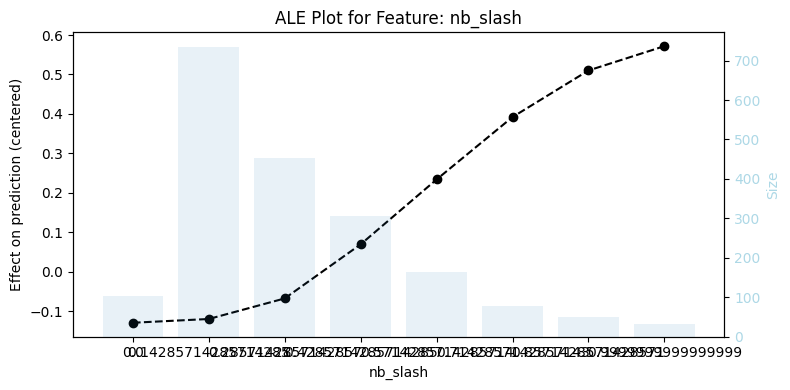

INFO:PyALE._ALE_generic:Continuous feature detected.


<Figure size 600x400 with 0 Axes>

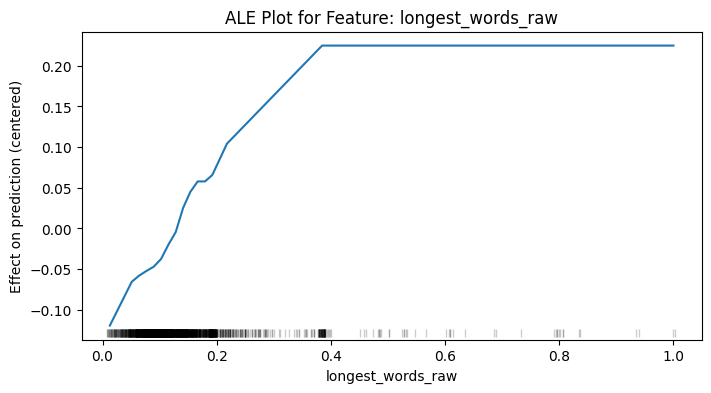

INFO:PyALE._ALE_generic:Continuous feature detected.


<Figure size 600x400 with 0 Axes>

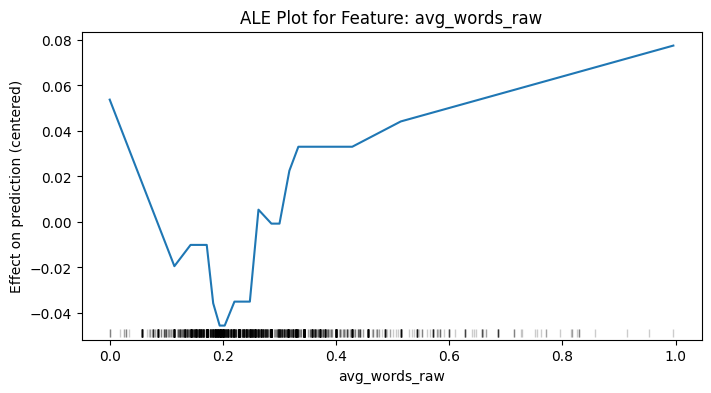

INFO:PyALE._ALE_generic:Continuous feature detected.


<Figure size 600x400 with 0 Axes>

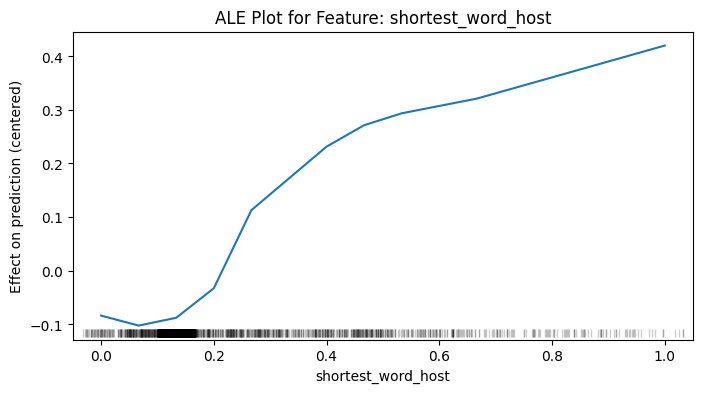

INFO:PyALE._ALE_generic:Continuous feature detected.


<Figure size 600x400 with 0 Axes>

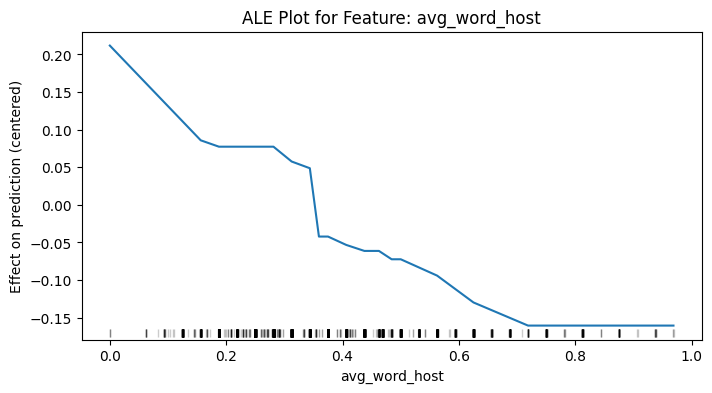

INFO:PyALE._ALE_generic:Continuous feature detected.


<Figure size 600x400 with 0 Axes>

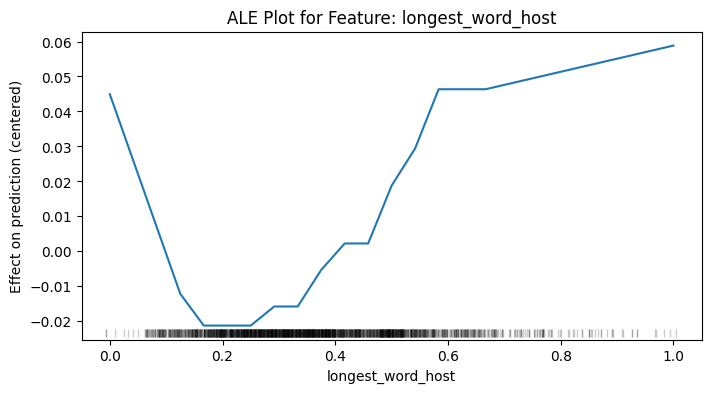

INFO:PyALE._ALE_generic:Continuous feature detected.


<Figure size 600x400 with 0 Axes>

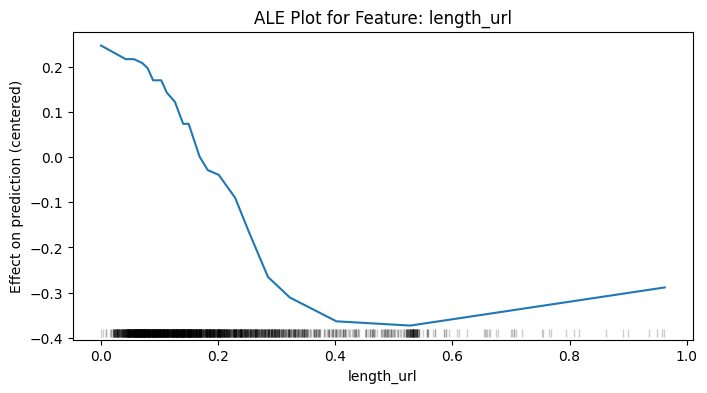

In [ ]:
from PyALE import ale
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the test data has the correct format
X_test_final = pd.DataFrame(X_test_final, columns=features)

# Custom wrapper to convert numpy input to DataFrame for SVM
class WrappedModel:
    def __init__(self, model, feature_names):
        self.model = model
        self.feature_names = feature_names

    def predict(self, X):
        df = pd.DataFrame(X, columns=self.feature_names)
        return self.model.predict(df)

# Wrap the SVM model
wrapped_svm = WrappedModel(svm_model, features)

# Plot ALE plots for all features
for feature in features:
    plt.figure(figsize=(6, 4))

    ale(
        X=X_test_final,
        model=wrapped_svm,
        feature=[feature],
        grid_size=20,
        include_CI=False,
        plot=True  # This handles the plotting
    )

    plt.title(f"ALE Plot for Feature: {feature}")
    plt.show()


#### LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b55ac317b768ab6b19f22139720ef7fc8a6130afa7c0286b35e9f48235278054
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd
import random

# Use your normalized test data
X_test_df = pd.DataFrame(X_test_final, columns=features)

# Wrap the SVM model to accept numpy input and return class probabilities
class SVMWrapper:
    def __init__(self, model, feature_names):
        self.model = model
        self.feature_names = feature_names

    def predict_proba(self, X):
        df = pd.DataFrame(X, columns=self.feature_names)
        # SVM with RBF doesn't have predict_proba by default unless you set probability=True
        # If you didn't, use decision_function instead and normalize
        decision = self.model.decision_function(df)
        prob = (decision - decision.min()) / (decision.max() - decision.min())
        prob = np.vstack([1 - prob, prob]).T  # shape: (n_samples, 2)
        return prob

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_test_df.values,
    feature_names=features,
    class_names=['legitimate', 'phishing'],
    mode='classification'
)

# Wrap the model
wrapped_model = SVMWrapper(svm_model, features)

# Pick 3 random samples from the test set
random_indices = random.sample(range(X_test_df.shape[0]), 3)

for idx in random_indices:
    sample = X_test_df.iloc[idx].values.reshape(1, -1)
    explanation = explainer.explain_instance(
        data_row=sample[0],
        predict_fn=wrapped_model.predict_proba,
        num_features=10  # Top 10 influential features
    )

    print(f"\n🔍 LIME Explanation for Test Sample Index {idx}")
    explanation.show_in_notebook(show_table=True)


🔍 LIME Explanation for Test Sample Index 1601



🔍 LIME Explanation for Test Sample Index 1770



🔍 LIME Explanation for Test Sample Index 430


#### SHAP

In [ ]:
!pip install shap

  0%|          | 0/1 [00:00<?, ?it/s]


🔍 SHAP Waterfall for Test Sample Index 1601


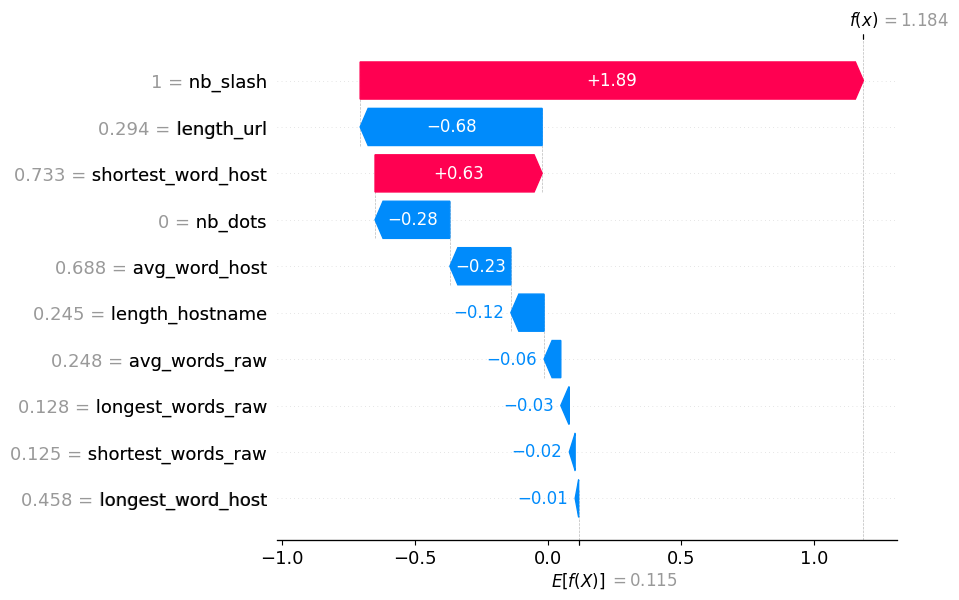

  0%|          | 0/1 [00:00<?, ?it/s]


🔍 SHAP Waterfall for Test Sample Index 1770


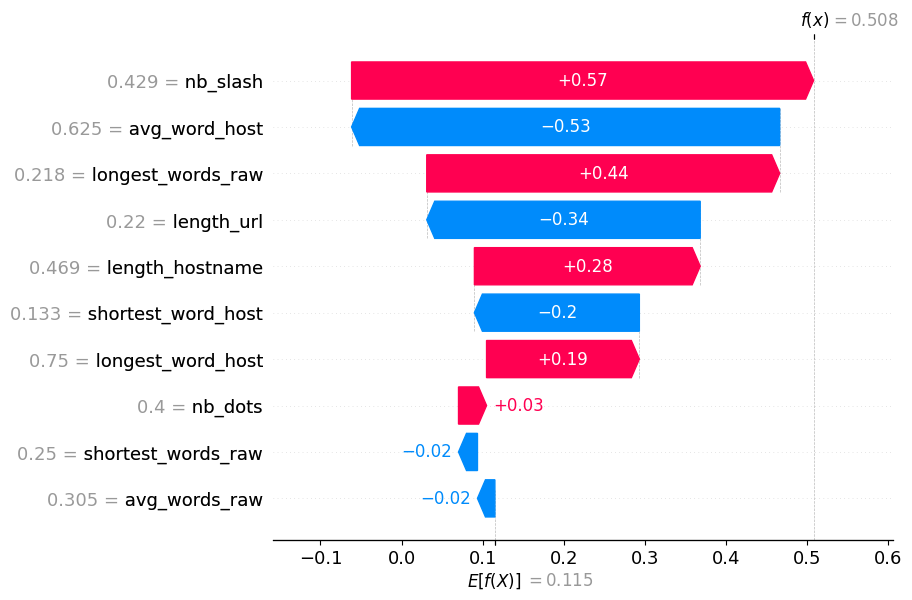

  0%|          | 0/1 [00:00<?, ?it/s]


🔍 SHAP Waterfall for Test Sample Index 430


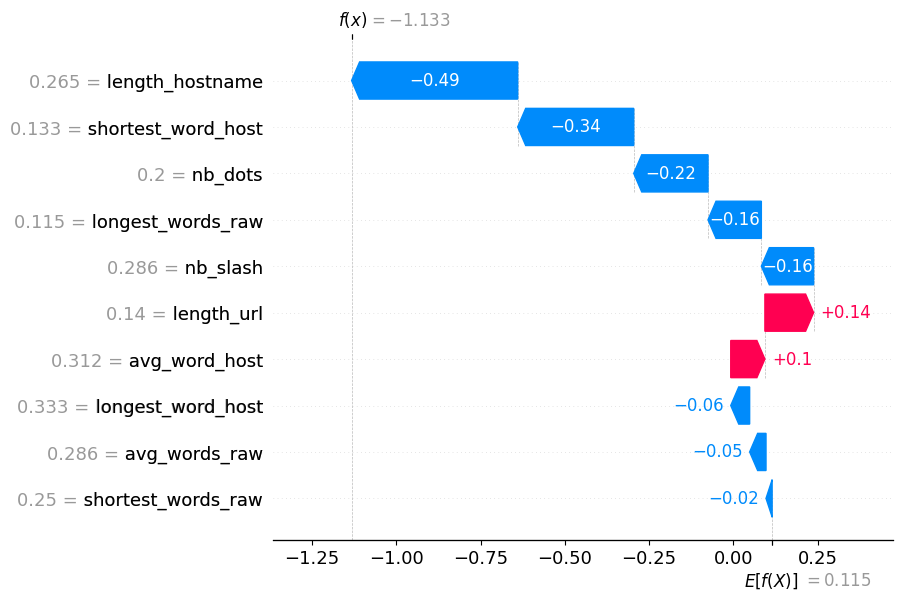

In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
import shap
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────────────────────
# STEP 0: LOAD NORMALIZED DATA AND SET UP FEATURES & TARGET
# ────────────────────────────────────────────────────────────────────────────────

# If you have already saved normalized CSVs, uncomment these lines to load them:
# train_normalized = pd.read_csv('/content/train_data_normalized.csv')
# test_normalized  = pd.read_csv('/content/test_data_normalized.csv')

# Otherwise, if you still have train_normalized and test_normalized as DataFrames
# in memory (from your earlier normalization step), just proceed to STEP 1.

# ────────────────────────────────────────────────────────────────────────────────
# STEP 1: SEPARATE FEATURES & TARGET FOR TRAIN AND TEST
# ────────────────────────────────────────────────────────────────────────────────

# We assume the target column is named 'status' and the rest are features:
X_train = train_normalized.drop(columns=['status'])
y_train = train_normalized['status']

X_test  = test_normalized.drop(columns=['status'])
y_test  = test_normalized['status']

# Keep track of feature names for later
features = X_train.columns.tolist()

# ────────────────────────────────────────────────────────────────────────────────
# STEP 2: TRAIN A NONLINEAR SVM (RBF KERNEL)
# ────────────────────────────────────────────────────────────────────────────────

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=False, random_state=0)
svm_model.fit(X_train, y_train)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 3: SELECT THE SAME THREE RANDOM TEST INDICES (FROM LIME)
# ────────────────────────────────────────────────────────────────────────────────

# Replace these with the exact indices you used in LIME:
random_indices = [1601, 1770, 430]

# Confirm these indices exist in X_test:
assert max(random_indices) < X_test.shape[0], f"Index out of bounds: test set has {X_test.shape[0]} rows."

# Create a DataFrame view of X_test to simplify indexing
X_test_df = pd.DataFrame(X_test.values, columns=features)

# Double‐check that the chosen rows contain no NaNs
assert not X_test_df.iloc[random_indices].isnull().values.any(), "Chosen test samples contain NaNs."

# ────────────────────────────────────────────────────────────────────────────────
# STEP 4: PREPARE BACKGROUND DATA FOR SHAP (KERNEL EXPLAINER)
# ────────────────────────────────────────────────────────────────────────────────

# Use up to 100 random rows from X_test_df as the “background” dataset (no NaNs)
background = X_test_df.sample(n=min(100, X_test_df.shape[0]), random_state=42)
assert not background.isnull().values.any(), "Background data contains NaNs."

# ────────────────────────────────────────────────────────────────────────────────
# STEP 5: INITIALIZE KERNEL EXPLAINER ON THE SVM DECISION FUNCTION
# ────────────────────────────────────────────────────────────────────────────────

# Wrap decision_function in a lambda that accepts NumPy arrays:
def decision_wrapper(X_numpy):
    """
    X_numpy: np.ndarray of shape (n_samples, n_features)
    Returns: np.ndarray of shape (n_samples,) with raw decision scores
    """
    df = pd.DataFrame(X_numpy, columns=features)
    return svm_model.decision_function(df).ravel()

# Create KernelExplainer using link="identity" to explain raw decision scores directly
explainer = shap.KernelExplainer(
    model=decision_wrapper,
    data=background.values,
    link="identity"
)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 6: COMPUTE AND PLOT SHAP WATERFALL FOR EACH CHOSEN SAMPLE
# ────────────────────────────────────────────────────────────────────────────────

for idx in random_indices:
    # 6.1) Extract the one‐row Series and its NumPy array
    sample_row   = X_test_df.iloc[idx]                 # pandas Series, shape=(n_features,)
    sample_array = sample_row.values.reshape(1, -1)     # NumPy array, shape=(1, n_features)

    # 6.2) Compute SHAP values via KernelExplainer
    shap_values = explainer.shap_values(sample_array)
    # Since we're explaining a single‐output (decision_function), shap_values is an array of shape (1, n_features)

    # 6.3) Flatten to a 1D array and grab the corresponding base value
    sv = np.array(shap_values).flatten()  # shape → (n_features,)
    base_val = explainer.expected_value     # a single float

    # 6.4) Sanity check: lengths must match
    assert sv.shape[0] == len(features) == sample_row.values.shape[0], (
        f"Shape mismatch: |sv|={sv.shape[0]}, |features|={len(features)}, |sample_row|={sample_row.values.shape[0]}"
    )

    # 6.5) Build a SHAP Explanation object for this sample
    explanation = shap.Explanation(
        values=sv,               # 1D array of length = n_features
        base_values=base_val,    # single float
        data=sample_row.values,  # 1D array of length = n_features
        feature_names=features
    )

    # 6.6) Display a SHAP waterfall plot
    print(f"\n🔍 SHAP Waterfall for Test Sample Index {idx}")
    shap.initjs()  # Needed for interactive JS in notebooks
    shap.plots.waterfall(explanation, max_display=10)


#### NAM

In [ ]:
# 1) Pin NumPy and SciPy (for NAM / scikit‐learn compatibility):
!pip install --upgrade numpy==1.23.5 scipy==1.9.3

# 2) Pin scikit‐learn to 1.1.3 (so that OneHotEncoder(sparse=False) still works):
!pip install --upgrade scikit-learn==1.1.3

# 3) Install PyTorch Lightning and loguru:
!pip install pytorch-lightning==2.5.1 loguru

# 4) Pin both jax and jaxlib to the same 0.4.13 release:
!pip install --upgrade jax==0.4.13 jaxlib==0.4.13

# 5) Finally, install nam itself without pulling in its broken “sklearn” dependency:
!pip install nam --no-deps


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 MB 10.4 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.5.1
    Uninstalling jaxlib-0.5.1:
      Successfully uninstalled jaxlib-0.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chex 0.1.89 requires jax>=0.4.27, but you have jax 0.4.13 which is incompatible.
chex 0.1.89 requires jaxlib>=0.4.27, but you have jaxlib 0.4.13 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
optax 0.2.4 requires jax>=0.4.27, but you have jax 0.4.13 which is incompatible.
optax 0.2.4 requires jaxlib>=0.4.27, but you have jaxlib 0.4.13 which is incompatible.
flax 0.10.6 requires jax>=0.5.1, but you have jax 0.4.13 which is incompatible.


In [ ]:
import numpy as np
import sklearn
import scipy
import torch
import jax

print("NumPy version:", np.__version__)          # should be 1.23.5
print("SciPy version:", scipy.__version__)       # should be 1.9.3
print("scikit-learn version:", sklearn.__version__)  # should be 1.1.3
print("PyTorch version:", torch.__version__)     # your installed torch (OK if 2.x)
print("JAX version:", jax.__version__)          # should be 0.4.13

# Now try importing NAM components:
from nam.config import defaults
from nam.data.base import NAMDataset
from nam.models import NAM, get_num_units
from nam.trainer import LitNAM

print("NAM imported successfully.")


ERROR:jax._src.xla_bridge:Jax plugin configuration error: Plugin module %s could not be loaded
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/xla_bridge.py", line 420, in discover_pjrt_plugins
    plugin_module = importlib.import_module(plugin_module_name)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/importlib/__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1147, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 690, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 940, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_r

NumPy version: 1.23.5
SciPy version: 1.9.3
scikit-learn version: 1.1.3
PyTorch version: 2.6.0+cu124
JAX version: 0.4.13
NAM imported successfully.


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
from nam.config import defaults
from nam.data.base import NAMDataset
from nam.models import NAM, get_num_units
from nam.trainer import LitNAM

print("Imports succeeded. All versions are now compatible.")



Imports succeeded. All versions are now compatible.


Epoch 1/20  Train Loss: 0.6445, Train Acc: 0.6467  Val Loss: 0.6066, Val Acc: 0.6901
Epoch 2/20  Train Loss: 0.5755, Train Acc: 0.7135  Val Loss: 0.5592, Val Acc: 0.7183
Epoch 3/20  Train Loss: 0.5466, Train Acc: 0.7284  Val Loss: 0.5379, Val Acc: 0.7345
Epoch 4/20  Train Loss: 0.5301, Train Acc: 0.7372  Val Loss: 0.5279, Val Acc: 0.7293
Epoch 5/20  Train Loss: 0.5217, Train Acc: 0.7382  Val Loss: 0.5198, Val Acc: 0.7387
Epoch 6/20  Train Loss: 0.5145, Train Acc: 0.7438  Val Loss: 0.5253, Val Acc: 0.7470
Epoch 7/20  Train Loss: 0.5104, Train Acc: 0.7507  Val Loss: 0.5104, Val Acc: 0.7376
Epoch 8/20  Train Loss: 0.5073, Train Acc: 0.7483  Val Loss: 0.5064, Val Acc: 0.7407
Epoch 9/20  Train Loss: 0.5010, Train Acc: 0.7539  Val Loss: 0.5032, Val Acc: 0.7538
Epoch 10/20  Train Loss: 0.4944, Train Acc: 0.7553  Val Loss: 0.5001, Val Acc: 0.7407
Epoch 11/20  Train Loss: 0.4891, Train Acc: 0.7601  Val Loss: 0.4956, Val Acc: 0.7626
Epoch 12/20  Train Loss: 0.4853, Train Acc: 0.7640  Val Loss: 0

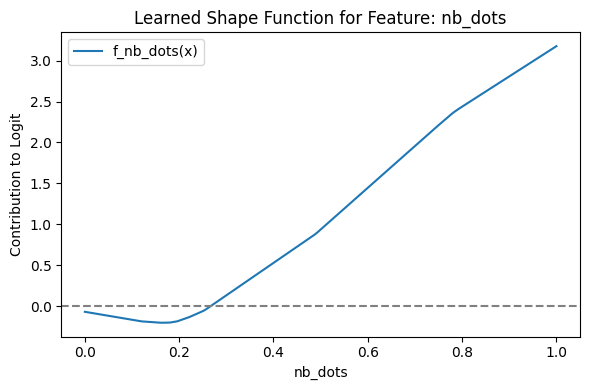

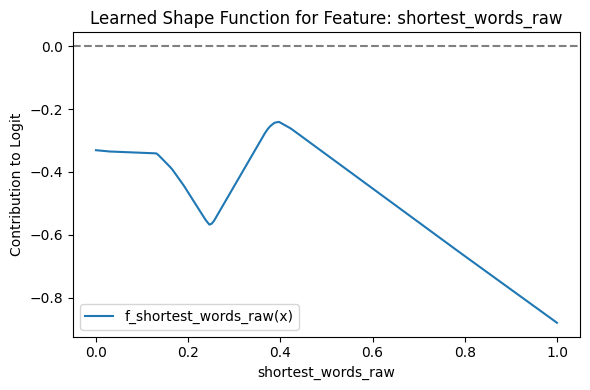

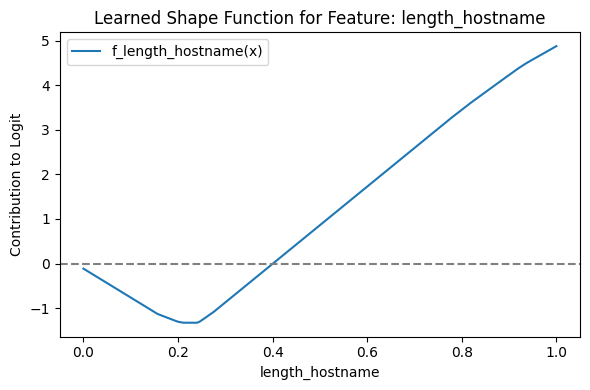

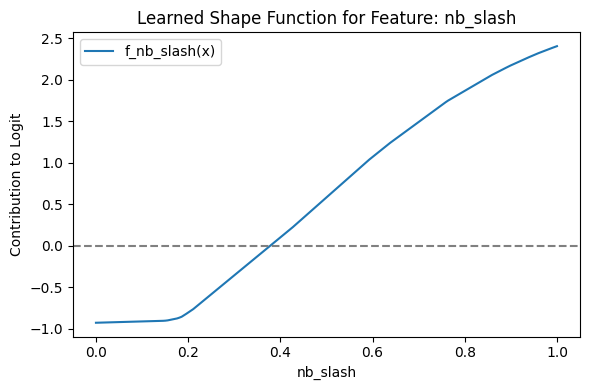

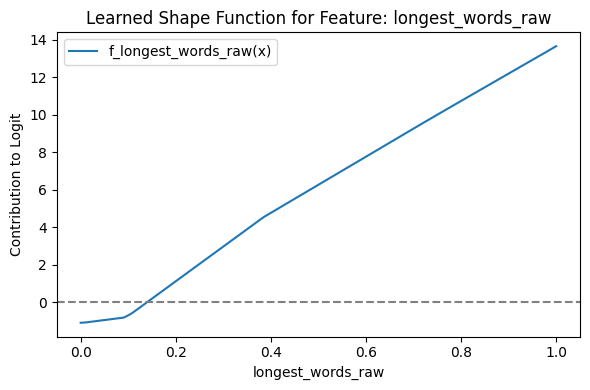

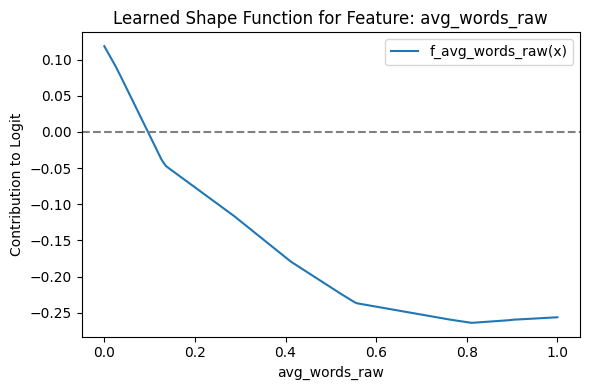

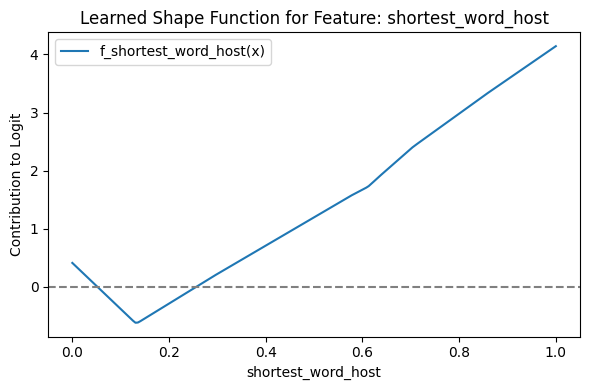

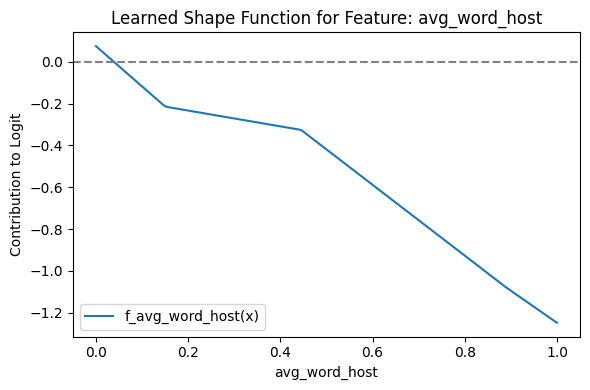

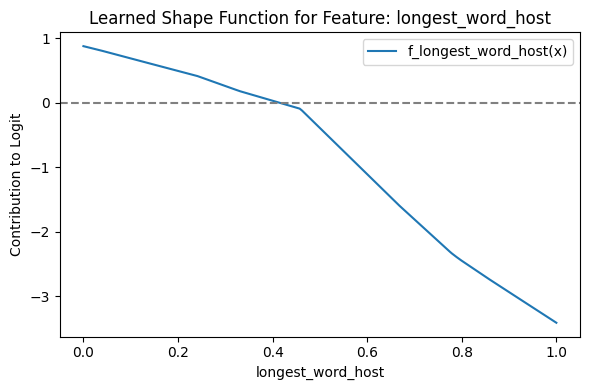

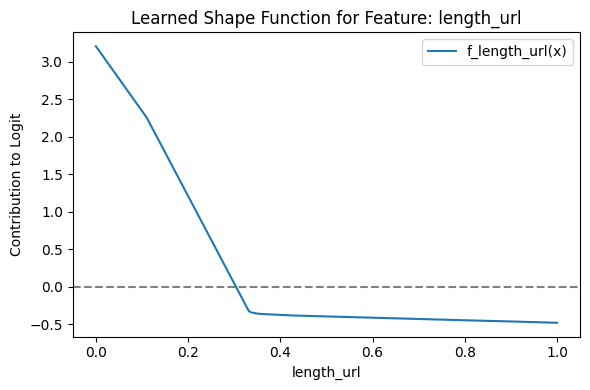

In [ ]:
# ────────────────────────────────────────────────────────────────────────────────
# Implementation of a Neural Additive Model (NAM) from scratch in PyTorch
#
# This code defines:
#   • A per‐feature subnetwork (FeatureNet) that takes a single scalar input
#   • A NAMClassifier that sums each FeatureNet’s output, applies a bias, and
#     feeds the sum through a sigmoid for binary classification
#   • Training and evaluation loops (accuracy + confusion matrix)
#   • Utility to visualize each learned shape function f_i(x_i)
#
# To run in Colab, first ensure you have the usual packages:
#     !pip install torch torchvision pandas scikit-learn matplotlib
# Then place your normalized train/test CSVs (with “status” as the target) in the environment,
# and adjust the file paths below.
# ────────────────────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt


# ────────────────────────────────────────────────────────────────────────────────
# STEP 0: LOAD NORMALIZED DATA
# ────────────────────────────────────────────────────────────────────────────────

# Adjust these paths as needed
train_df = pd.read_csv('/content/train_data_normalized.csv')
test_df  = pd.read_csv('/content/test_data_normalized.csv')

# Assume "status" is the binary target (0 = legitimate, 1 = phishing)
features = [c for c in train_df.columns if c != 'status']
num_features = len(features)

# Extract NumPy arrays
X_train_np = train_df[features].values.astype(np.float32)  # shape = (n_train, num_features)
y_train_np = train_df['status'].values.astype(np.int64)    # shape = (n_train,)

X_test_np  = test_df[features].values.astype(np.float32)   # shape = (n_test, num_features)
y_test_np  = test_df['status'].values.astype(np.int64)     # shape = (n_test,)

# Convert to torch tensors
X_train = torch.from_numpy(X_train_np)  # (n_train, num_features)
y_train = torch.from_numpy(y_train_np)  # (n_train,)
X_test  = torch.from_numpy(X_test_np)   # (n_test, num_features)
y_test  = torch.from_numpy(y_test_np)   # (n_test,)

# Build simple TensorDatasets and DataLoaders
batch_size = 64
train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)


# ────────────────────────────────────────────────────────────────────────────────
# STEP 1: DEFINE A SMALL PER‐FEATURE MLP (FeatureNet)
#
# Each FeatureNet takes a single‐dimensional input x_i ∈ ℝ and outputs a scalar f_i(x_i).
# You can adjust hidden_sizes to control capacity.
# ────────────────────────────────────────────────────────────────────────────────

class FeatureNet(nn.Module):
    def __init__(self, hidden_sizes=[32, 32]):
        super().__init__()
        layers = []
        in_dim = 1
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU(inplace=True))
            in_dim = h
        # Final output is a scalar contribution
        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_i):
        """
        x_i: tensor of shape (batch_size, 1) containing the i-th feature
        returns: tensor of shape (batch_size, 1), the single‐feature contribution
        """
        return self.mlp(x_i)


# ────────────────────────────────────────────────────────────────────────────────
# STEP 2: DEFINE THE NAMClassifier
#
# The NAMClassifier contains one FeatureNet per feature. In forward():
#   1) Split the input X into columns X[:, i:i+1]
#   2) Feed each column to its FeatureNet to get a (batch_size, 1) tensor
#   3) Sum all feature‐contributions (and add a bias term)
#   4) Apply sigmoid to produce a probability for class=1
# ────────────────────────────────────────────────────────────────────────────────

class NAMClassifier(nn.Module):
    def __init__(self, num_features, hidden_sizes=None):
        """
        num_features: int, number of input features (K)
        hidden_sizes: list of ints for each hidden layer in every FeatureNet
                      e.g. [32, 32]. If None, defaults to [32, 32].
        """
        super().__init__()
        if hidden_sizes is None:
            hidden_sizes = [32, 32]

        # Create a ModuleList of K separate FeatureNets
        self.feature_nets = nn.ModuleList([
            FeatureNet(hidden_sizes=hidden_sizes) for _ in range(num_features)
        ])

        # A single learnable bias term
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, X):
        """
        X: tensor of shape (batch_size, num_features)
        returns: logits of shape (batch_size,)
        """
        # Sum contributions from each feature net
        total = self.bias  # starts as shape (1,)
        for i, net in enumerate(self.feature_nets):
            # Extract i-th feature as shape (batch_size, 1)
            x_i = X[:, i].unsqueeze(1)  # (batch_size, 1)
            contrib_i = net(x_i)        # (batch_size, 1)
            total = total + contrib_i   # broadcast adds (batch_size, 1)

        # total is (batch_size, 1) → flatten to (batch_size,)
        logits = total.squeeze(1)
        return logits

    def predict_proba(self, X):
        """
        Returns probability of class=1 for each row in X.
        """
        with torch.no_grad():
            logits = self.forward(X)
            probs = torch.sigmoid(logits)
        return probs

    def predict(self, X, threshold=0.5):
        """
        Returns predicted class labels (0 or 1) for each row in X.
        """
        probs = self.predict_proba(X)
        return (probs >= threshold).long()


# ────────────────────────────────────────────────────────────────────────────────
# STEP 3: TRAINING LOOP
#
# We train with binary cross‐entropy on logits (BCEWithLogitsLoss).
# ────────────────────────────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).float()

        optimizer.zero_grad()
        logits = model(X_batch)                # shape = (batch_size,)
        loss = criterion(logits, y_batch)      # BCEWithLogitsLoss
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y_batch.cpu().long().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).float()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y_batch.cpu().long().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    epoch_acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    return epoch_loss, epoch_acc, cm


# ────────────────────────────────────────────────────────────────────────────────
# STEP 4: PUT IT ALL TOGETHER
# ────────────────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
hidden_sizes = [32, 32]    # each FeatureNet has two hidden layers of size 32
learning_rate = 1e-3
num_epochs = 20

# Instantiate model, loss, optimizer
model = NAMClassifier(num_features=num_features, hidden_sizes=hidden_sizes).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_cm = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {epoch}/{num_epochs}  "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Final evaluation on test set
test_loss, test_acc, test_cm = evaluate(model, test_loader, criterion, device)
print("\n=== Final Test Results ===")
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
print("Test Confusion Matrix:")
print(test_cm)


# ────────────────────────────────────────────────────────────────────────────────
# STEP 5: VISUALIZE LEARNED SHAPE FUNCTIONS FOR ALL FEATURES
#
# For each feature i, we sweep over its observed range and plot f_i(x_i).
# ────────────────────────────────────────────────────────────────────────────────

model.eval()

# Grab min/max of each feature from the training DataFrame
mins = train_df[features].min().values.astype(np.float32)
maxs = train_df[features].max().values.astype(np.float32)

for i, feat_name in enumerate(features):
    x_min, x_max = mins[i], maxs[i]
    xs = np.linspace(x_min, x_max, 200, dtype=np.float32).reshape(-1, 1)  # (200, 1)

    with torch.no_grad():
        subnet = model.feature_nets[i]
        contrib = subnet(torch.from_numpy(xs).to(device))  # shape = (200,1)
        contrib = contrib.cpu().numpy().flatten()          # shape = (200,)

    plt.figure(figsize=(6, 4))
    plt.plot(xs, contrib, label=f"f_{feat_name}(x)")
    plt.axhline(0, color='gray', linestyle='--')
    plt.xlabel(feat_name)
    plt.ylabel("Contribution to Logit")
    plt.title(f"Learned Shape Function for Feature: {feat_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


#### Anchor

In [ ]:
import numpy as np
import pandas as pd
import random
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# ────────────────────────────────────────────────────────────────────────────────
# STEP 0: LOAD YOUR NORMALIZED PHISHING DATA AND TRAIN A BLACK‐BOX MODEL
# ────────────────────────────────────────────────────────────────────────────────

# Replace these paths with wherever your normalized CSVs live
train_df = pd.read_csv('/content/train_data_normalized.csv')
test_df  = pd.read_csv('/content/test_data_normalized.csv')

# The target column is “status”, and all other columns are numeric features
features = [c for c in train_df.columns if c != 'status']

X_train = train_df[features].values
y_train = train_df['status'].values

X_test  = test_df[features].values
y_test  = test_df['status'].values

# Train a nonlinear SVM (RBF kernel) as our black‐box f(·)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=False, random_state=0)
svm_model.fit(X_train, y_train)

# Pre‐compute predictions on the test set
y_test_pred = svm_model.predict(X_test)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 1: PICK ONE RANDOM TEST INSTANCE
# ────────────────────────────────────────────────────────────────────────────────

random.seed(42)
idx = random.randrange(X_test.shape[0])
x0 = X_test[idx]
y0 = int(y_test_pred[idx])  # the SVM’s predicted label for the chosen instance

print(f"Chosen test index = {idx}, predicted label = {y0}")

# ────────────────────────────────────────────────────────────────────────────────
# STEP 2: SEARCH FOR A “ONE‐FEATURE” RULE THAT SATISFIES
#            Precision ≥ 0.8  AND  Coverage ≥ 0.4
#
# We will look for a rule of the form:
#     “feature_j ≤ t”   or   “feature_j > t”
# where t = x0[j], the value of feature j on the chosen instance.
#
# For each feature j:
#   • Let R_minus_j  = { i ∈ test : X_test[i,j] ≤ x0[j] }
#   • Let R_plus_j   = { i ∈ test : X_test[i,j] >  x0[j] }
#   • If within R_minus_j the SVM predicts y0 with fraction ≥ 0.8, and |R_minus_j|/|test| ≥ 0.4,
#       we accept “feature_j ≤ x0[j]”.
#   • Otherwise if within R_plus_j the SVM predicts y0 with fraction ≥ 0.8, and |R_plus_j|/|test| ≥ 0.4,
#       we accept “feature_j > x0[j]”.
#   • We stop as soon as we find any such rule.
#
# This is a simplification of the Anchor concept restricted to single‐feature split.
# ────────────────────────────────────────────────────────────────────────────────

n_test = X_test.shape[0]
found_rule = None

for j, feat_name in enumerate(features):
    t = x0[j]

    # Evaluate "feature_j ≤ t"
    mask_le = (X_test[:, j] <= t)
    if mask_le.sum() / n_test >= 0.4:
        subset_preds = y_test_pred[mask_le]
        precision_le = (subset_preds == y0).mean()
        coverage_le = mask_le.sum() / n_test
        if precision_le >= 0.8:
            found_rule = (feat_name, "<=", t, precision_le, coverage_le)
            break

    # Evaluate "feature_j > t"
    mask_gt = (X_test[:, j] > t)
    if mask_gt.sum() / n_test >= 0.4:
        subset_preds = y_test_pred[mask_gt]
        precision_gt = (subset_preds == y0).mean()
        coverage_gt = mask_gt.sum() / n_test
        if precision_gt >= 0.8:
            found_rule = (feat_name, ">", t, precision_gt, coverage_gt)
            break

if found_rule is None:
    print("No single‐feature rule with Precision ≥ 0.8 and Coverage ≥ 0.4 was found.")
else:
    feat, op, thresh, prec, cov = found_rule
    print(f"Rule found: IF {feat} {op} {thresh:.4f} THEN predicted_label = {y0}")
    print(f"  Precision = {prec:.4f}, Coverage = {cov:.4f}")


Chosen test index = 1309, predicted label = 1
No single‐feature rule with Precision ≥ 0.8 and Coverage ≥ 0.4 was found.


In [9]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from alibi.explainers import AnchorTabular

# ────────────────────────────────────────────────────────────────────────────────
# STEP 1: Load normalized data & train an RBF‐SVM
# ────────────────────────────────────────────────────────────────────────────────

train_df = pd.read_csv('/content/train_data_normalized.csv')
test_df  = pd.read_csv('/content/test_data_normalized.csv')

# “status” is the 0/1 target; remaining columns are numeric features
features = [c for c in train_df.columns if c != 'status']

X_train = train_df[features].values
y_train = train_df['status'].values

X_test  = test_df[features].values
y_test  = test_df['status'].values

svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=0)
svm.fit(X_train, y_train)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 2: Wrap SVM.predict_proba for Alibi
# ────────────────────────────────────────────────────────────────────────────────

def predict_fn(x: np.ndarray) -> np.ndarray:
    """
    Alibi expects a function taking (n_samples, n_features) and returning
    (n_samples, n_classes) probability arrays.
    """
    return svm.predict_proba(x)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 3: Initialize & fit AnchorTabular
# ────────────────────────────────────────────────────────────────────────────────

explainer = AnchorTabular(
    predictor=predict_fn,
    feature_names=features,
    categorical_names={},  # all features are continuous
    dtype=np.float32,
    ohe=False,
    seed=0
)
explainer.fit(X_train)  # bins continuous features, builds samplers, etc.

# ────────────────────────────────────────────────────────────────────────────────
# STEP 4: Choose a test instance to explain
# ────────────────────────────────────────────────────────────────────────────────

i = 42  # pick any valid index < len(X_test)
x0 = X_test[i].reshape(1, -1)
pred0 = svm.predict(x0)[0]
print(f"Explaining test‐instance idx={i}, SVM predicted label = {pred0}\n")

# ────────────────────────────────────────────────────────────────────────────────
# STEP 5: Run the Anchor explanation
# ────────────────────────────────────────────────────────────────────────────────

explanation = explainer.explain(
    x0,
    threshold=0.8,            # require ≥80% precision
    tau=0.05,                 # Hoeffding confidence → 95%
    beam_size=5,
    coverage_samples=1000,
    precision_samples=500,
    n_covered_ex=1000,
    verbose=False
)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 6: Read the human‐readable rule from explanation.data['names']
# ────────────────────────────────────────────────────────────────────────────────

# explanation.data['names'] is a list of strings like "feat2 <= 0.345", etc.
conds = explanation.data.get('names', [])

precision = explanation.data.get('precision', None)
coverage  = explanation.data.get('coverage', None)

print("Anchor rule:")
print("  IF  " + " AND ".join(conds) + f"  THEN predict = {pred0}")
print(f"Estimated Precision = {precision:.4f}")
print(f"Estimated Coverage  = {coverage:.4f}")


Explaining test‐instance idx=42, SVM predicted label = 1

Anchor rule:
  IF    THEN predict = 1
Estimated Precision = 0.8171
Estimated Coverage  = 0.3590


In [8]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from alibi.explainers import AnchorTabular

# ────────────────────────────────────────────────────────────────────────────────
# STEP 1: Load normalized data & train an RBF‐SVM
# ────────────────────────────────────────────────────────────────────────────────

train_df = pd.read_csv('/content/train_data_normalized.csv')
test_df  = pd.read_csv('/content/test_data_normalized.csv')

# “status” is the 0/1 target; remaining columns are numeric features
features = [c for c in train_df.columns if c != 'status']

X_train = train_df[features].values
y_train = train_df['status'].values

X_test  = test_df[features].values
y_test  = test_df['status'].values

svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=0)
svm.fit(X_train, y_train)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 2: Wrap SVM.predict_proba for Alibi
# ────────────────────────────────────────────────────────────────────────────────

def predict_fn(x: np.ndarray) -> np.ndarray:
    """
    Alibi expects a function taking (n_samples, n_features) and returning
    (n_samples, n_classes) probability arrays.
    """
    return svm.predict_proba(x)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 3: Initialize & fit AnchorTabular
# ────────────────────────────────────────────────────────────────────────────────

explainer = AnchorTabular(
    predictor=predict_fn,
    feature_names=features,
    categorical_names={},  # all features are continuous
    dtype=np.float32,
    ohe=False,
    seed=0
)
explainer.fit(X_train)  # bins continuous features, builds samplers, etc.

# ────────────────────────────────────────────────────────────────────────────────
# STEP 4: Choose a test instance to explain
# ────────────────────────────────────────────────────────────────────────────────

i = 42  # pick any valid index < len(X_test)
x0 = X_test[i].reshape(1, -1)
pred0 = svm.predict(x0)[0]
print(f"Explaining test‐instance idx={i}, SVM predicted label = {pred0}\n")

# ────────────────────────────────────────────────────────────────────────────────
# STEP 5: Run the Anchor explanation
# ────────────────────────────────────────────────────────────────────────────────

explanation = explainer.explain(
    x0,
    threshold=0.8,            # require ≥80% precision
    tau=0.05,                 # Hoeffding confidence → 95%
    beam_size=5,
    coverage_samples=100,
    precision_samples=500,
    n_covered_ex=1000,
    verbose=False
)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 6: Read the human‐readable rule from explanation.data['names']
# ────────────────────────────────────────────────────────────────────────────────

# explanation.data['names'] is a list of strings like "feat2 <= 0.345", etc.
conds = explanation.data.get('names', [])

precision = explanation.data.get('precision', None)
coverage  = explanation.data.get('coverage', None)

print("Anchor rule:")
print("  IF  " + " AND ".join(conds) + f"  THEN predict = {pred0}")
print(f"Estimated Precision = {precision:.4f}")
print(f"Estimated Coverage  = {coverage:.4f}")


Explaining test‐instance idx=42, SVM predicted label = 1

Anchor rule:
  IF    THEN predict = 1
Estimated Precision = 0.8145
Estimated Coverage  = 0.4300


In [7]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from alibi.explainers import AnchorTabular

# ────────────────────────────────────────────────────────────────────────────────
# STEP 1: Load normalized data & train an RBF‐SVM
# ────────────────────────────────────────────────────────────────────────────────

train_df = pd.read_csv('/content/train_data_normalized.csv')
test_df  = pd.read_csv('/content/test_data_normalized.csv')

# “status” is the 0/1 target; remaining columns are numeric features
features = [c for c in train_df.columns if c != 'status']

X_train = train_df[features].values
y_train = train_df['status'].values

X_test  = test_df[features].values
y_test  = test_df['status'].values

svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=0)
svm.fit(X_train, y_train)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 2: Wrap SVM.predict_proba for Alibi
# ────────────────────────────────────────────────────────────────────────────────

def predict_fn(x: np.ndarray) -> np.ndarray:
    """
    Alibi expects a function taking (n_samples, n_features) and returning
    (n_samples, n_classes) probability arrays.
    """
    return svm.predict_proba(x)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 3: Initialize & fit AnchorTabular
# ────────────────────────────────────────────────────────────────────────────────

explainer = AnchorTabular(
    predictor=predict_fn,
    feature_names=features,
    categorical_names={},  # all features are continuous
    dtype=np.float32,
    ohe=False,
    seed=0
)
explainer.fit(X_train)  # bins continuous features, builds samplers, etc.

# ────────────────────────────────────────────────────────────────────────────────
# STEP 4: Choose a test instance to explain
# ────────────────────────────────────────────────────────────────────────────────

i = 298  # pick any valid index < len(X_test)
x0 = X_test[i].reshape(1, -1)
pred0 = svm.predict(x0)[0]
print(f"Explaining test‐instance idx={i}, SVM predicted label = {pred0}\n")

# ────────────────────────────────────────────────────────────────────────────────
# STEP 5: Run the Anchor explanation
# ────────────────────────────────────────────────────────────────────────────────

explanation = explainer.explain(
    x0,
    threshold=0.8,            # require ≥80% precision
    tau=0.05,                 # Hoeffding confidence → 95%
    beam_size=5,
    coverage_samples=100,
    precision_samples=500,
    n_covered_ex=1000,
    verbose=False
)

# ────────────────────────────────────────────────────────────────────────────────
# STEP 6: Read the human‐readable rule from explanation.data['names']
# ────────────────────────────────────────────────────────────────────────────────

# explanation.data['names'] is a list of strings like "feat2 <= 0.345", etc.
conds = explanation.data.get('names', [])

precision = explanation.data.get('precision', None)
coverage  = explanation.data.get('coverage', None)

print("Anchor rule:")
print("  IF  " + " AND ".join(conds) + f"  THEN predict = {pred0}")
print(f"Estimated Precision = {precision:.4f}")
print(f"Estimated Coverage  = {coverage:.4f}")


Explaining test‐instance idx=298, SVM predicted label = 0

Anchor rule:
  IF    THEN predict = 0
Estimated Precision = 0.8266
Estimated Coverage  = 0.3600
